Fisher test of AGN lensing with the latest technologies (new lensing transformations, flexible Fisher matrix).

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import gwfast.network as network
import gwfast.waveforms as waveforms
from gwfast.gwfastGlobals import detectors as det_dict, detPath
from gwfast.detector import Detector
from gwfast.signals import BasicGWSignal, AGNLensedGWSignal, GeneralLensedGWSignal
from gwfast.fisherTools import reduce_Fisher_matrix, CovMatr, plot_corners

LSC Algorithm Library (LAL) is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH
TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [2]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

# H1_BBH = BasicGWSignal(wf_model=wf_model, detector=H1, fmin=10)
# L1_BBH = BasicGWSignal(wf_model=wf_model, detector=L1, fmin=10)
# V1_BBH = BasicGWSignal(wf_model=wf_model, detector=V1, fmin=10)
# HLV_BBH = network.DetNet({'H1': H1_BBH, 'L1': L1_BBH, 'V1': V1_BBH})

# H1_GEN = GeneralLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
# L1_GEN = GeneralLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
# V1_GEN = GeneralLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
# HLV_GEN = network.DetNet({'H1': H1_GEN, 'L1': L1_GEN, 'V1': V1_GEN})

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [6]:
events = {
    'Mc':np.array([30, 30]), 'eta':np.array([0.24, 0.24]), 
    'chi1z':np.array([0.3, 0.3]), 'chi2z':np.array([0.5, 0.5]), 
    'iota':np.array([0.9*np.pi/2, 0.9*np.pi/2]), 'tcoal':np.array([0, 0]), 'phase':np.array([2, 2]), 'psi':np.array([1, 1]), 
    'R_orbit':np.array([20, 20]), 'M_lz':np.array([2e4, 2e4]), 'src_pos':np.array([0.5, 0.5]), 
    'dL':np.array([0.8, 0.8]), 'theta':np.array([2.34, 2.34]), 'phi':np.array([5.43, 5.43])
}
events = {key: val.astype(np.float64) for key, val in events.items()}

In [7]:
SNR_AGN = HLV_AGN.SNR(events)
# SNR_GEN = HLV_GEN.SNR(events)
# SNR_BBH = HLV_BBH.SNR(events)
print("SNR with AGN lensing:", SNR_AGN)
# print("SNR with general lensing:", SNR_GEN)
# print("SNR without lensing:", SNR_BBH)

SNR with AGN lensing: [43.41096603 43.41096603]


Computing Fisher for H1...
Computing Fisher for L1...
Computing Fisher for V1...
Done.


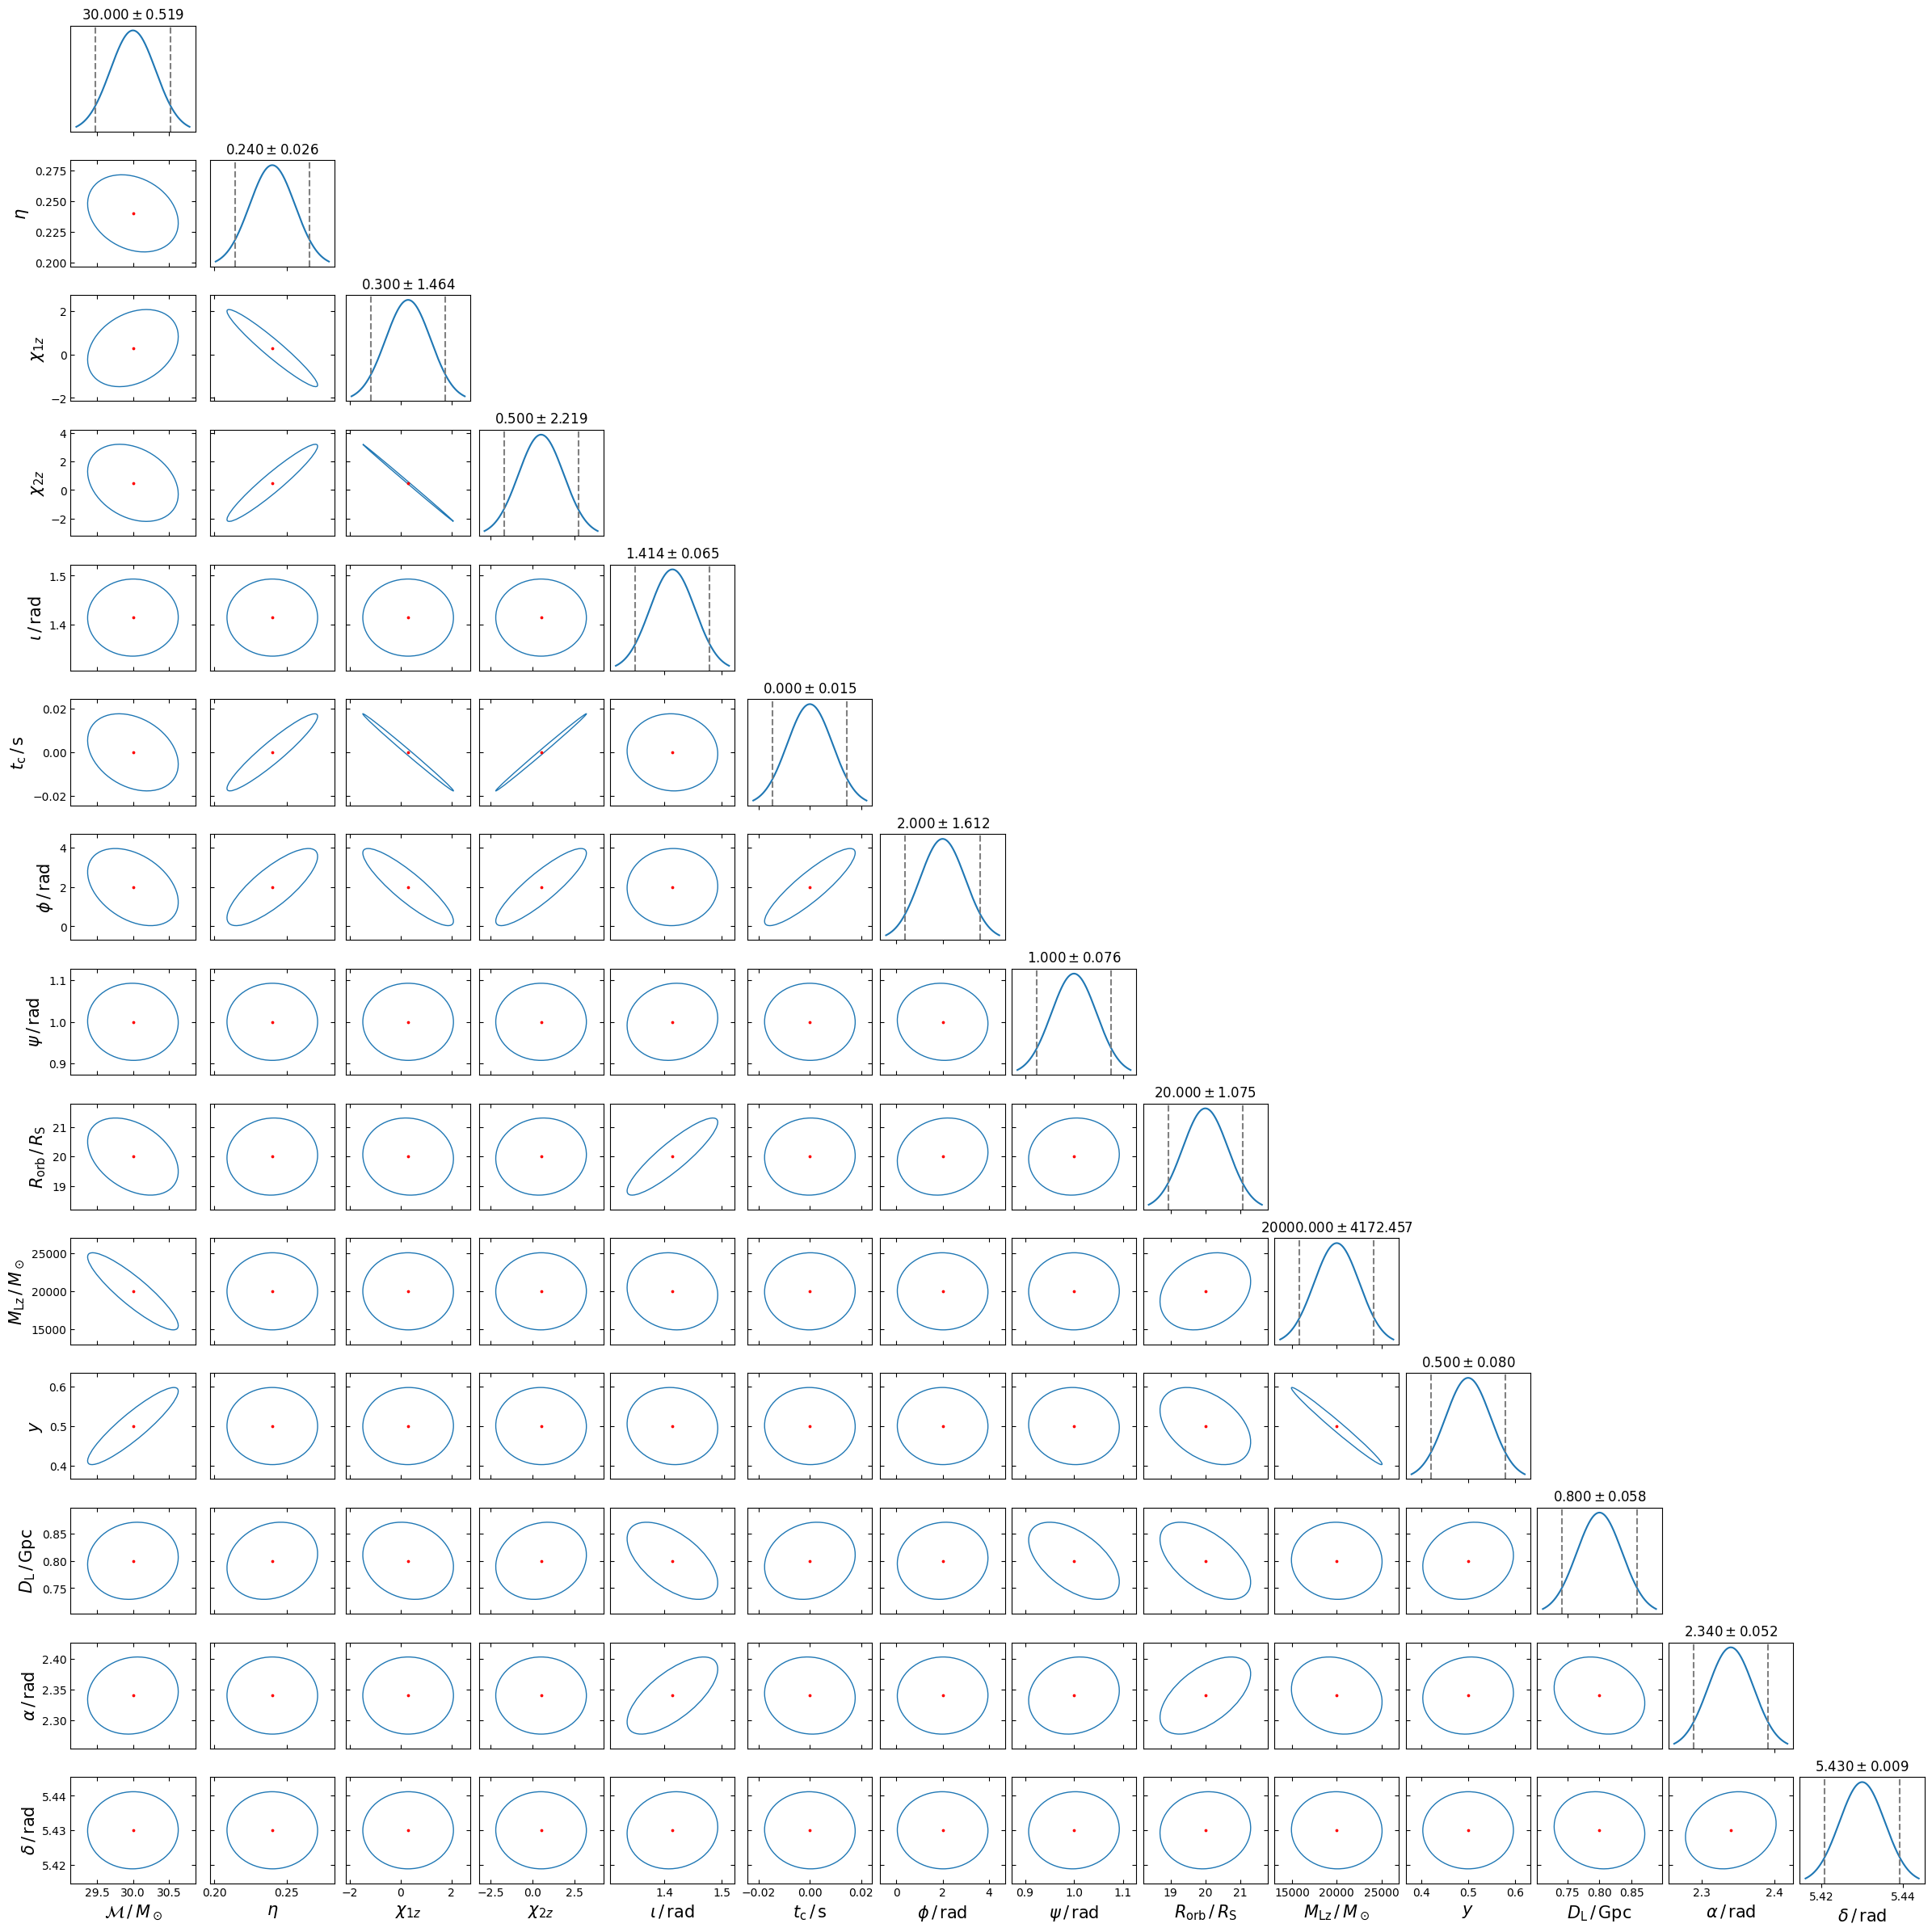

In [8]:
fisher_AGN = HLV_AGN.FisherMatr(events, res=1000)
keys = list(events.keys()).copy()
reduced_fisher_AGN, _ = reduce_Fisher_matrix(fisher_AGN, keys=keys)
reduced_fisher_AGN = np.array(reduced_fisher_AGN)
reduced_cov_AGN, ie = CovMatr(reduced_fisher_AGN)

idx = 0
indices = np.arange(0, len(keys))
parameters = {key: val[idx] for key, val in events.items()}
labels = {
    'Mc': r'${\cal M}\,/\,M_\odot$',
    'eta': r'$\eta$',
    'dL': r'$D_{\rm L}\,/\,{\rm Gpc}$',
    'theta': r'$\alpha\,/\,{\rm rad}$',
    'phi': r'$\delta\,/\,{\rm rad}$',
    'iota': r'$\iota\,/\,{\rm rad}$',
    'psi': r'$\psi\,/\,{\rm rad}$',
    'tcoal': r'$t_{\rm c}\,/\,{\rm s}$',
    'phase': r'$\phi\,/\,{\rm rad}$',
    'chi1z': r'$\chi_{1z}$',
    'chi2z': r'$\chi_{2z}$',
    'R_orbit': r'$R_{\rm orb}\,/\,R_{\rm S}$',
    'M_lz': r'$M_{\rm Lz}\,/\,M_\odot$',
    'src_pos': r'$y$',
    'delta_iota': r'$\Delta \iota\,/\,{\rm rad}$',
    'delta_phase': r'$\Delta \phi\,/\,{\rm rad}$',
    'delta_time': r'$\Delta t\,/\,{\rm s}$',
    'relative_mass': r'${\cal M}_2 \,/\,{\cal M}_1$',
    'relative_distance': r'$D_{L,2} \,/\,D_{L,1}$',
}
fig = plot_corners(
    reduced_cov_AGN[:, :, idx], keys, indices, 
    event=parameters, labels=labels, color='C0'
)